# Visualize SCALP-lite Embedding

Choose one of the registered datasets in the first code cell. The selected dataset sets the input path, output path, batch key, label key, preprocessing defaults, and graph defaults.

In [1]:
from pathlib import Path

from scalp_lite import ScalpEstimator


# Choose a dataset by editing selected_dataset.
DATASETS = {
    # Complete development example: real time slices in Stage and lineage labels.
    "zebrafish": {
        "input": "data/cellrank-zebrafish.h5ad",
        "batch_key": "Stage",
        "label_key": "lineages",
        "preprocess": {"normalize": False, "hvg_flavor": "variance", "create_artificial_batch": False},
        "graph": {"n_neighbors": 15, "intra_fraction": 0.5, "n_inter_edges": 10, "assignment_quantile": 0.3, "hubness_correction": "csls", "hubness_k": 10, "edge_weighting": "binary", "symmetrize": True},
    },
    # Best integration benchmark: five pancreas studies/platforms with shared cell-type labels.
    "pancreas": {
        "input": "data/pancreas_normalized.h5ad",
        "batch_key": "study",
        "label_key": "cell_type",
        "preprocess": {"normalize": False, "hvg_flavor": "variance", "min_gene_counts": 0, "max_cells": 6000, "create_artificial_batch": False},
        "graph": {"n_neighbors": 15, "intra_fraction": 0.5, "n_inter_edges": 2, "assignment_quantile": 0.8, "hubness_correction": "csls", "hubness_k": 10, "edge_weighting": "binary", "symmetrize": True},
    },
    # Small smoke-test dataset: no real batch, so preprocessing creates deterministic split_* batches.
    "pbmc3k": {
        "input": "data/scanpy-pbmc3k.h5ad",
        "batch_key": "batch",
        "label_key": "leiden",
        "preprocess": {"normalize": "auto", "hvg_flavor": "cell_ranger", "create_artificial_batch": True},
        "graph": {"n_neighbors": 15, "intra_fraction": 0.5, "n_inter_edges": 1, "assignment_quantile": 0.95, "hubness_correction": "csls", "hubness_k": 10, "edge_weighting": "binary", "symmetrize": True},
    },
}

selected_dataset = "pancreas"
dataset = DATASETS[selected_dataset]
input_path = Path("..") / dataset["input"]
output_path = input_path.with_name(f"{input_path.stem}-scalp.h5ad")
batch_key = dataset["batch_key"]
label_key = dataset["label_key"]

# Estimator stores default keys and graph parameters for the workflow.
estimator = ScalpEstimator(
    batch_key=batch_key,
    label_key=label_key,
    # Number of PCA components used as the high-dimensional representation for graph construction.
    n_components=40,
    # Seed used by PCA, subsampling, and graph layout initialization.
    random_state=0,
)

selected_dataset, input_path, batch_key, label_key


('pancreas',
 PosixPath('../data/pancreas_normalized.h5ad'),
 'study',
 'cell_type')

In [ ]:
preprocess_params = {
    # Number of highly variable genes to keep before PCA.
    "n_top_genes": 2000,
    # Optional cell cap for faster experiments; None keeps all cells.
    "max_cells": None,
    # Optional minimum detected genes per cell; None disables cell filtering.
    "min_cell_genes": None,
    # Remove genes observed fewer than this many total counts.
    "min_gene_counts": 3,
    **dataset["preprocess"],
}

adata = estimator.to_data(input_path)
adata = estimator.preprocess(adata, **preprocess_params)
adata


AnnData object with n_obs × n_vars = 6000 × 1000
    obs: 'batch', 'study', 'cell_type', 'size_factors'
    obsm: 'X_pca'

In [3]:
graph_params = dataset["graph"]
graph = estimator.data_to_graph(adata, **graph_params)
adata.obsm["X_scalp"] = estimator.graph_to_vector(graph)

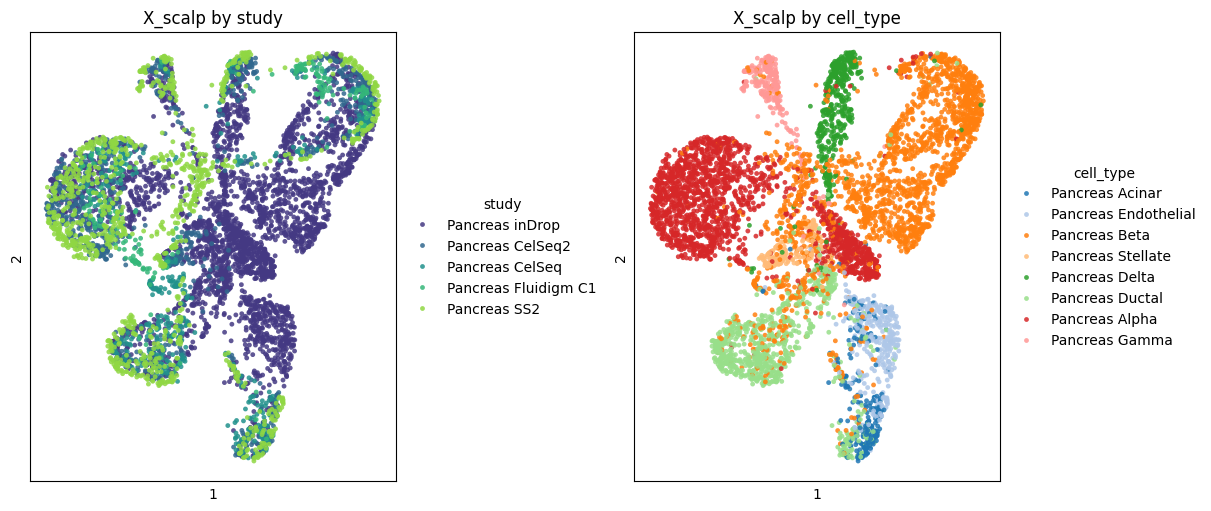

In [4]:
estimator.plot(
    adata,
    # SCALP low-dimensional graph embedding created by graph_to_vector; UMAP here.
    embedding_key="X_scalp",
);


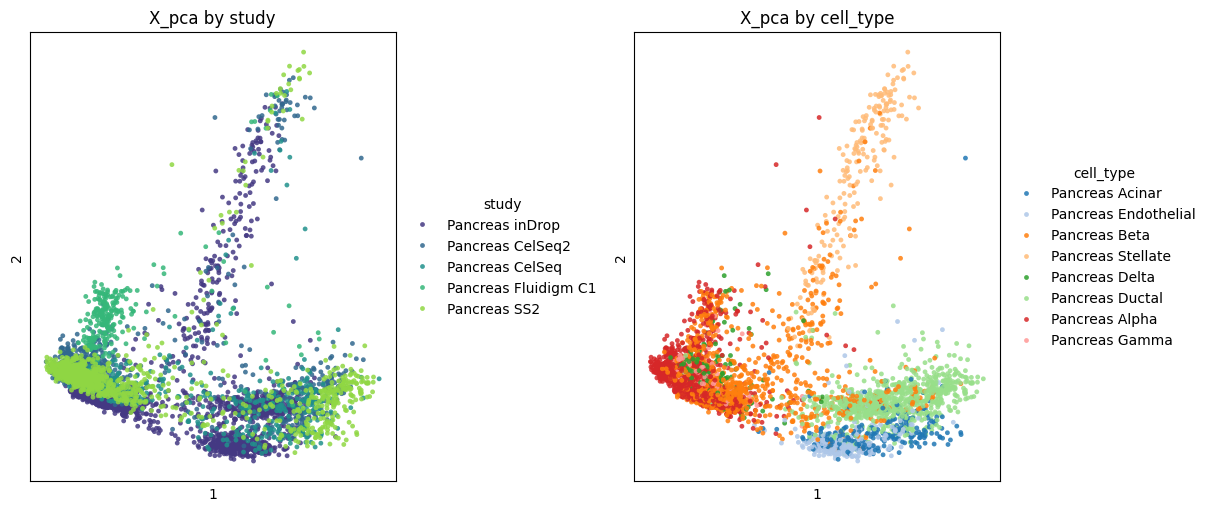

In [5]:
estimator.plot(
    adata,
    # PCA coordinates created or refreshed during preprocessing; used as graph input.
    embedding_key="X_pca",
);

In [6]:
estimator.save(adata, output_path)
output_path


PosixPath('../data/pancreas_normalized-scalp.h5ad')